# 1. Exploration — Données RH générales (`general_data.csv`)

Ce notebook explore le fichier principal contenant les informations démographiques,
professionnelles et salariales de chaque employé de HumanForYou.

**Variable cible** : `Attrition` (l'employé a-t-il quitté l'entreprise en 2016 ?)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

## 1.1 Chargement et aperçu

In [2]:
df_general = pd.read_csv("data/general_data.csv")
print(f"Dimensions : {df_general.shape[0]} lignes × {df_general.shape[1]} colonnes")
df_general.head()

Dimensions : 4410 lignes × 24 colonnes


,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeID,Gender,JobLevel,JobRole,MaritalStatus,MonthlyIncome,NumCompaniesWorked,Over18,PercentSalaryHike,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsSinceLastPromotion,YearsWithCurrManager
0,51,No,Travel_Rarely,Sales,6,2,Life Sciences,1,1,Female,1,Healthcare Representative,Married,131160,1.0,Y,11,8,0,1.0,6,1,0,0
1,31,Yes,Travel_Frequently,Research & Development,10,1,Life Sciences,1,2,Female,1,Research Scientist,Single,41890,0.0,Y,23,8,1,6.0,3,5,1,4
2,32,No,Travel_Frequently,Research & Development,17,4,Other,1,3,Male,4,Sales Executive,Married,193280,1.0,Y,15,8,3,5.0,2,5,0,3
3,38,No,Non-Travel,Research & Development,2,5,Life Sciences,1,4,Male,3,Human Resources,Married,83210,3.0,Y,11,8,3,13.0,5,8,7,5
4,32,No,Travel_Rarely,Research & Development,10,1,Medical,1,5,Male,1,Sales Executive,Single,23420,4.0,Y,12,8,2,9.0,2,6,0,4


## 1.2 Types et valeurs manquantes

In [3]:
df_general.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4410 entries, 0 to 4409
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      4410 non-null   int64  
 1   Attrition                4410 non-null   object 
 2   BusinessTravel           4410 non-null   object 
 3   Department               4410 non-null   object 
 4   DistanceFromHome         4410 non-null   int64  
 5   Education                4410 non-null   int64  
 6   EducationField           4410 non-null   object 
 7   EmployeeCount            4410 non-null   int64  
 8   EmployeeID               4410 non-null   int64  
 9   Gender                   4410 non-null   object 
 10  JobLevel                 4410 non-null   int64  
 11  JobRole                  4410 non-null   object 
 12  MaritalStatus            4410 non-null   object 
 13  MonthlyIncome            4410 non-null   int64  
 14  NumCompaniesWorked      

In [4]:
# Comptage des valeurs manquantes par colonne
missing = df_general.isnull().sum()
missing = missing[missing > 0]
if missing.empty:
    print("Aucune valeur manquante détectée.")
else:
    print("Valeurs manquantes :")
    print(missing)

Valeurs manquantes :
NumCompaniesWorked    19
TotalWorkingYears      9
dtype: int64


## 1.3 Vérification de la clé primaire (`EmployeeID`)

In [5]:
n_unique = df_general["EmployeeID"].nunique()
n_total = len(df_general)
print(f"Nombre d'EmployeeID uniques : {n_unique} / {n_total} lignes")
print(f"EmployeeID est une clé primaire : {n_unique == n_total}")

Nombre d'EmployeeID uniques : 4410 / 4410 lignes
EmployeeID est une clé primaire : True


## 1.4 Statistiques descriptives — Variables numériques

In [6]:
df_general.describe()

,Age,DistanceFromHome,Education,EmployeeCount,EmployeeID,JobLevel,MonthlyIncome,NumCompaniesWorked,PercentSalaryHike,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsSinceLastPromotion,YearsWithCurrManager
count,4410.000000,4410.000000,4410.000000,4410.0,4410.000000,4410.000000,4410.000000,4391.000000,4410.000000,4410.0,4410.000000,4401.000000,4410.000000,4410.000000,4410.000000,4410.000000
mean,36.923810,9.192517,2.912925,1.0,2205.500000,2.063946,65029.312925,2.694830,15.209524,8.0,0.793878,11.279936,2.799320,7.008163,2.187755,4.123129
std,9.133301,8.105026,1.023933,0.0,1273.201673,1.106689,47068.888559,2.498887,3.659108,0.0,0.851883,7.782222,1.288978,6.125135,3.221699,3.567327
min,18.000000,1.000000,1.000000,1.0,1.000000,1.000000,10090.000000,0.000000,11.000000,8.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,2.000000,2.000000,1.0,1103.250000,1.000000,29110.000000,1.000000,12.000000,8.0,0.000000,6.000000,2.000000,3.000000,0.000000,2.000000
50%,36.000000,7.000000,3.000000,1.0,2205.500000,2.000000,49190.000000,2.000000,14.000000,8.0,1.000000,10.000000,3.000000,5.000000,1.000000,3.000000
75%,43.000000,14.000000,4.000000,1.0,3307.750000,3.000000,83800.000000,4.000000,18.000000,8.0,1.000000,15.000000,3.000000,9.000000,3.000000,7.000000
max,60.000000,29.000000,5.000000,1.0,4410.000000,5.000000,199990.000000,9.000000,25.000000,8.0,3.000000,40.000000,6.000000,40.000000,15.000000,17.000000


## 1.5 Statistiques descriptives — Variables catégorielles

In [7]:
cat_cols = df_general.select_dtypes(include="object").columns.tolist()
print(f"Colonnes catégorielles : {cat_cols}\n")

for col in cat_cols:
    print(f"--- {col} ---")
    print(df_general[col].value_counts())
    print()

Colonnes catégorielles : ['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18']

--- Attrition ---
Attrition
No     3699
Yes     711
Name: count, dtype: int64

--- BusinessTravel ---
BusinessTravel
Travel_Rarely        3129
Travel_Frequently     831
Non-Travel            450
Name: count, dtype: int64

--- Department ---
Department
Research & Development    2883
Sales                     1338
Human Resources            189
Name: count, dtype: int64

--- EducationField ---
EducationField
Life Sciences       1818
Medical             1392
Marketing            477
Technical Degree     396
Other                246
Human Resources       81
Name: count, dtype: int64

--- Gender ---
Gender
Male      2646
Female    1764
Name: count, dtype: int64

--- JobRole ---
JobRole
Sales Executive              978
Research Scientist           876
Laboratory Technician        777
Manufacturing Director       435
Healthcare Representative    393
Manager

## 1.6 Colonnes à variance nulle ou quasi-nulle

In [8]:
# Colonnes qui n'apportent pas d'information discriminante
for col in df_general.columns:
    n_vals = df_general[col].nunique()
    if n_vals <= 1:
        print(f"  {col} : {n_vals} valeur(s) unique(s) → à supprimer")

  EmployeeCount : 1 valeur(s) unique(s) → à supprimer
  Over18 : 1 valeur(s) unique(s) → à supprimer
  StandardHours : 1 valeur(s) unique(s) → à supprimer


## 1.7 Distribution de la variable cible `Attrition`

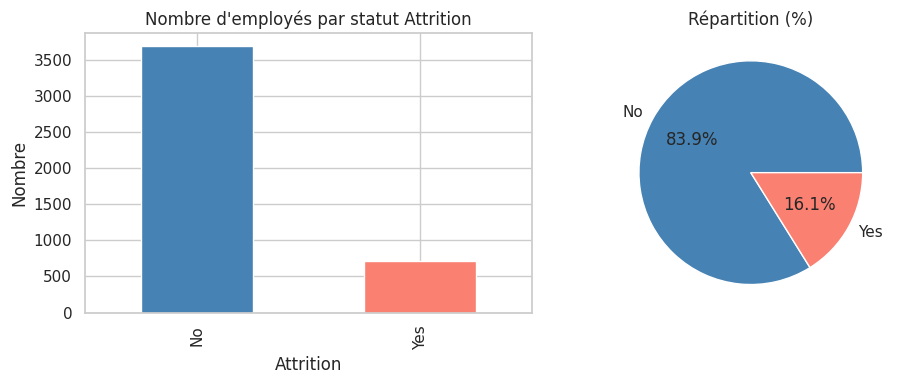

Attrition
No     3699
Yes     711
Name: count, dtype: int64

Taux d'attrition : 16.1%


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Comptage
attrition_counts = df_general["Attrition"].value_counts()
attrition_counts.plot.bar(ax=axes[0], color=["steelblue", "salmon"])
axes[0].set_title("Nombre d'employés par statut Attrition")
axes[0].set_ylabel("Nombre")

# Pourcentage
attrition_pct = df_general["Attrition"].value_counts(normalize=True) * 100
attrition_pct.plot.pie(ax=axes[1], autopct="%.1f%%", colors=["steelblue", "salmon"])
axes[1].set_title("Répartition (%)")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

print(attrition_counts)
print(f"\nTaux d'attrition : {attrition_pct['Yes']:.1f}%")

## 1.8 Distributions des variables numériques clés

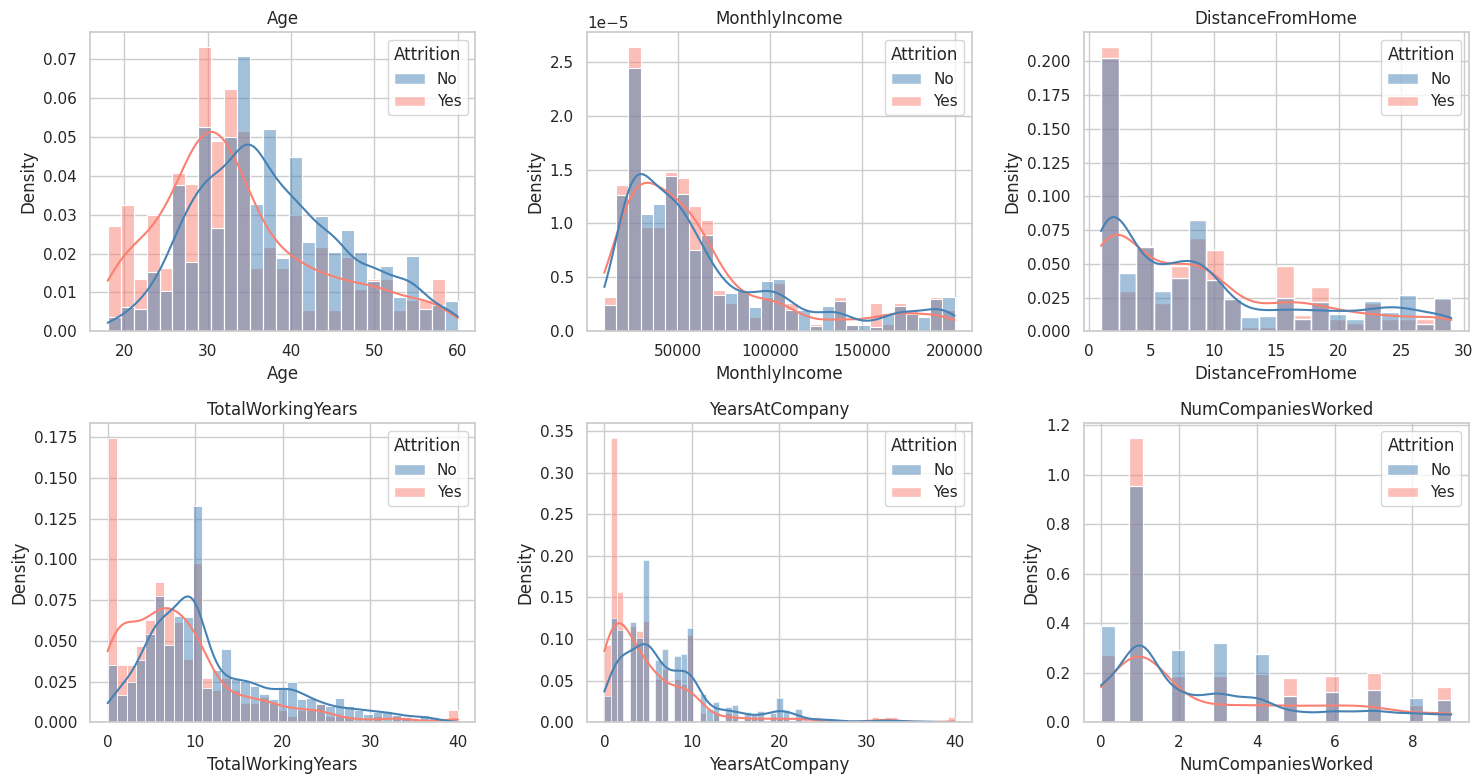

In [10]:
num_cols = ["Age", "MonthlyIncome", "DistanceFromHome", "TotalWorkingYears",
            "YearsAtCompany", "NumCompaniesWorked"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.ravel(), num_cols):
    sns.histplot(data=df_general, x=col, hue="Attrition", kde=True, ax=ax,
                 palette={"No": "steelblue", "Yes": "salmon"}, stat="density",
                 common_norm=False)
    ax.set_title(col)
plt.tight_layout()
plt.show()

## 1.9 Taux d'attrition par variable catégorielle

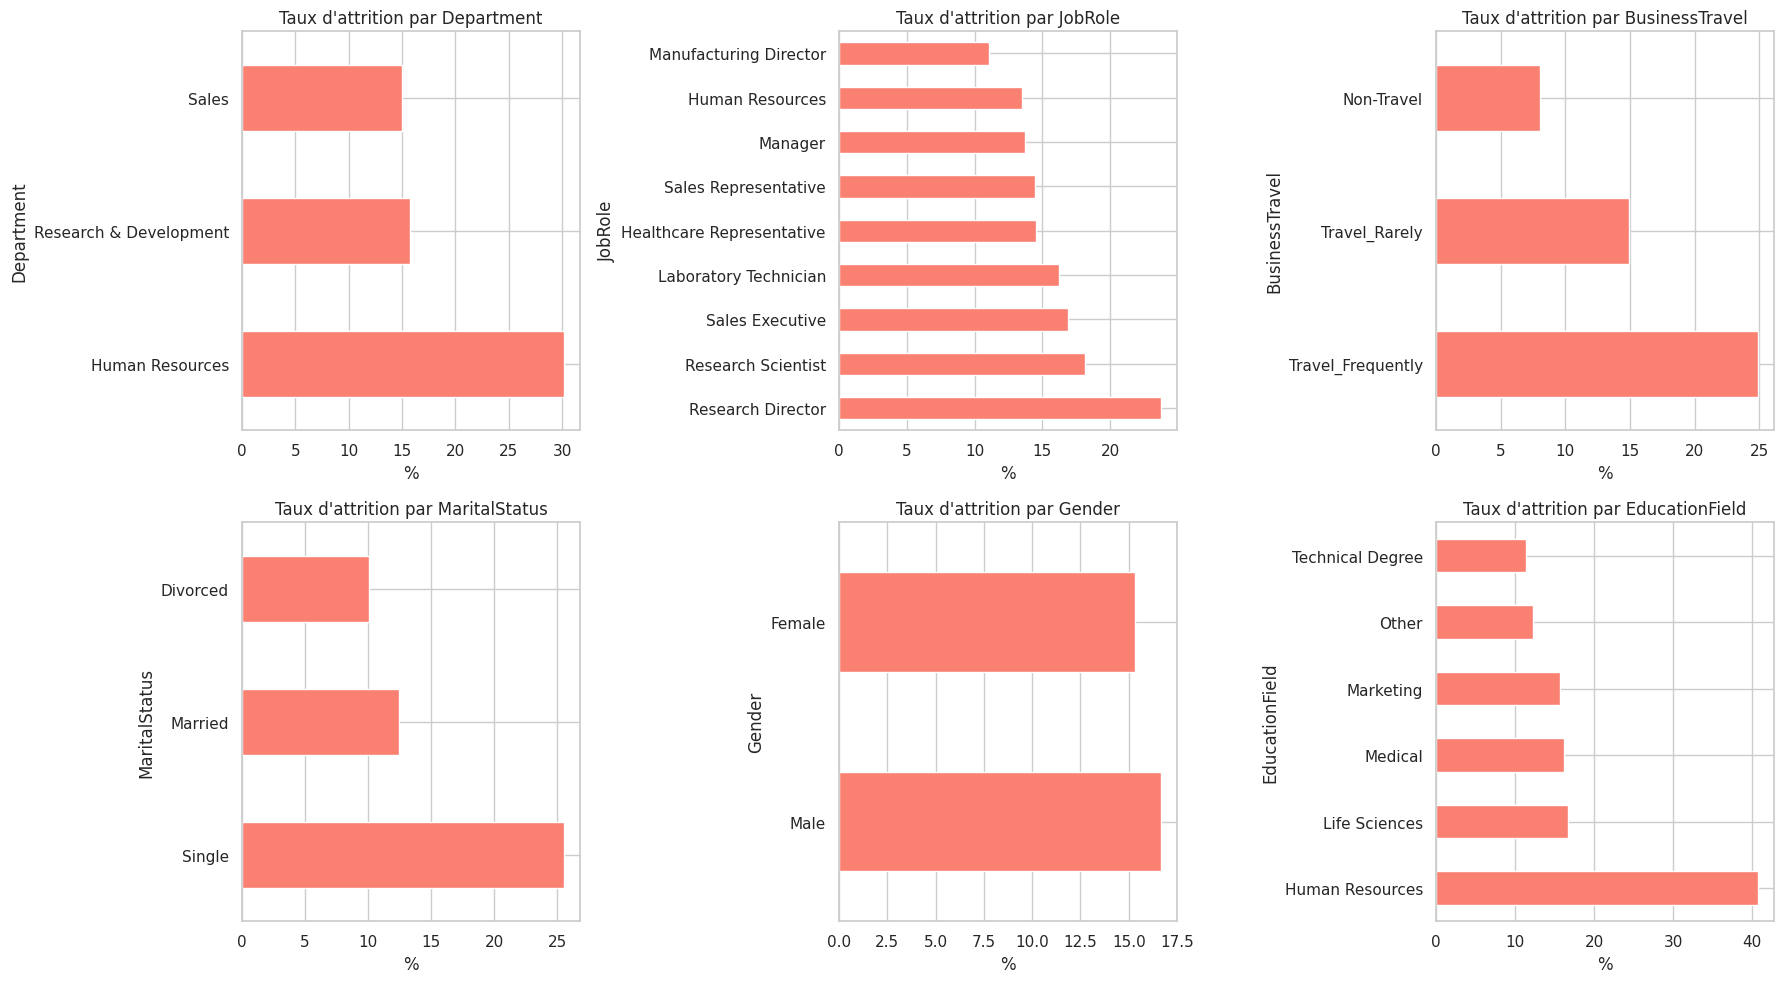

In [11]:
cat_features = ["Department", "JobRole", "BusinessTravel", "MaritalStatus",
                "Gender", "EducationField"]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, col in zip(axes.ravel(), cat_features):
    rates = df_general.groupby(col)["Attrition"].apply(
        lambda x: (x == "Yes").mean() * 100
    ).sort_values(ascending=False)
    rates.plot.barh(ax=ax, color="salmon")
    ax.set_title(f"Taux d'attrition par {col}")
    ax.set_xlabel("%")
plt.tight_layout()
plt.show()